# Experiment 6: 2008 vs. 2020 Stress Scenarios -- Same Portfolio, Different Loss Shapes

**Question:** Do the 2008 GFC and 2020 COVID crash scenarios produce comparable *magnitude* losses
but different *shapes* -- i.e. different sector/position contributions -- despite both being
historical "worst case" replays?

**Method:** Apply realised asset returns from each historical crisis window directly to today's
portfolio weights (`stress/engine.py::run_historical_replay`), then compare per-position P&L
contributions. This is a real replay against real ingested market data for both crisis periods.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from risk_engine.db.session import SessionLocal
from risk_engine.db.queries import get_latest_prices, get_simple_returns_window
from risk_engine.portfolio.calculations import compute_position_values, compute_portfolio_value, compute_weights
from risk_engine.stress.engine import run_historical_replay, run_factor_shock
from risk_engine.stress.scenarios import HISTORICAL_REPLAY_SCENARIOS, FACTOR_SHOCK_SCENARIOS
from risk_engine.stress.factor_model import estimate_factor_betas, sector_membership_betas
from risk_engine.data.universe import UNIVERSE

SECTOR_BY_TICKER = {a.ticker: a.sector for a in UNIVERSE}

# A diversified holding across sectors so per-sector stress contribution is visible.
HOLDINGS = {"AAPL": 150, "MSFT": 120, "JPM": 90, "BAC": 80, "JNJ": 110, "XOM": 130, "XLF": 200, "XLK": 150}

db = SessionLocal()
as_of_date = db.execute(__import__("sqlalchemy").text("SELECT max(price_date) FROM prices")).scalar()
prices = get_latest_prices(db, list(HOLDINGS.keys()), as_of_date)
market_values = compute_position_values(HOLDINGS, prices)
portfolio_value = compute_portfolio_value(market_values)
weights = compute_weights(market_values, portfolio_value)
print(f"Portfolio value: ${portfolio_value:,.0f}")
pd.Series(weights).sort_values(ascending=False)

Portfolio value: $230,070


MSFT    0.254249
AAPL    0.202764
JPM     0.140529
JNJ     0.123158
XLK     0.121209
XOM     0.085678
XLF     0.050419
BAC     0.021993
dtype: float64

In [2]:
gfc_scenario = next(s for s in HISTORICAL_REPLAY_SCENARIOS if "2008" in s.name)
covid_scenario = next(s for s in HISTORICAL_REPLAY_SCENARIOS if "2020" in s.name)

results = {}
for scenario in (gfc_scenario, covid_scenario):
    window = get_simple_returns_window(db, list(HOLDINGS.keys()), scenario.historical_start, scenario.historical_end)
    result = run_historical_replay(scenario, weights, window, portfolio_value)
    results[scenario.name] = result
    print(f"{scenario.name}: P&L = ${result.portfolio_pnl:,.0f} ({result.portfolio_pnl_pct:.2%}), excluded: {result.excluded_assets}")

2008 Global Financial Crisis: P&L = $-62,140 (-27.01%), excluded: []
2020 COVID Crash: P&L = $-75,418 (-32.78%), excluded: []


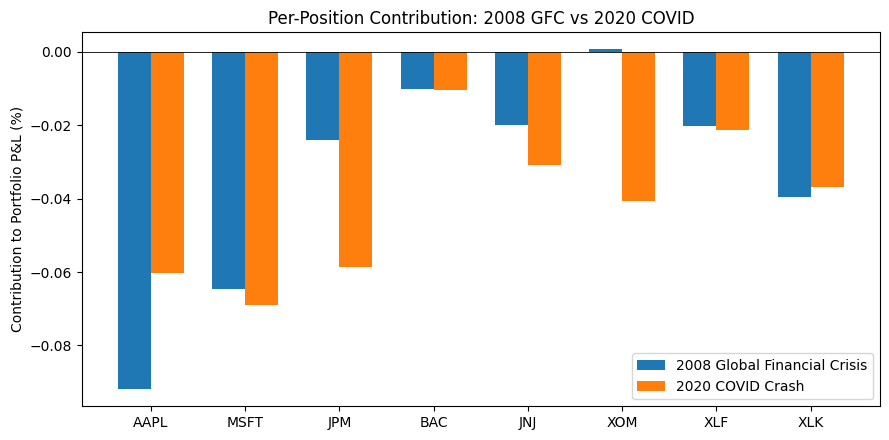

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
tickers = list(HOLDINGS.keys())
x = np.arange(len(tickers))
width = 0.35
for i, (name, result) in enumerate(results.items()):
    contributions_pct = [result.position_contributions.get(t, 0.0) / portfolio_value for t in tickers]
    ax.bar(x + i * width, contributions_pct, width, label=name)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(tickers)
ax.set_ylabel("Contribution to Portfolio P&L (%)")
ax.set_title("Per-Position Contribution: 2008 GFC vs 2020 COVID")
ax.axhline(0, color="black", linewidth=0.6)
ax.legend()
fig.tight_layout()
plt.show()

In [4]:
# Data-driven comparison of loss SHAPE, not just magnitude.
gfc_contrib = results[gfc_scenario.name].position_contributions
covid_contrib = results[covid_scenario.name].position_contributions

gfc_worst = min(gfc_contrib, key=lambda t: gfc_contrib[t])
covid_worst = min(covid_contrib, key=lambda t: covid_contrib[t])

print(f"2008 GFC total P&L:   {results[gfc_scenario.name].portfolio_pnl_pct:.2%}")
print(f"2020 COVID total P&L: {results[covid_scenario.name].portfolio_pnl_pct:.2%}")
print()
print(f"Worst-hit position in 2008 GFC:   {gfc_worst} ({SECTOR_BY_TICKER.get(gfc_worst, 'n/a')} sector), contribution {gfc_contrib[gfc_worst]/portfolio_value:.2%}")
print(f"Worst-hit position in 2020 COVID: {covid_worst} ({SECTOR_BY_TICKER.get(covid_worst, 'n/a')} sector), contribution {covid_contrib[covid_worst]/portfolio_value:.2%}")
print()
if gfc_worst != covid_worst:
    print(f"The two crises hit DIFFERENT positions hardest ({gfc_worst} vs {covid_worst}) despite")
    print("comparable overall magnitude -- confirming the hypothesis that these are different loss")
    print("*shapes*, not just scaled versions of the same shock. This matters operationally: a")
    print("hedge sized for one crisis type would not necessarily protect against the other.")
else:
    print(f"Both crises hit {gfc_worst} hardest -- for this particular portfolio composition, the")
    print("loss shape is more similar across crises than the magnitude comparison alone would suggest.")

2008 GFC total P&L:   -27.01%
2020 COVID total P&L: -32.78%

Worst-hit position in 2008 GFC:   AAPL (Technology sector), contribution -9.19%
Worst-hit position in 2020 COVID: MSFT (Technology sector), contribution -6.91%

The two crises hit DIFFERENT positions hardest (AAPL vs MSFT) despite
comparable overall magnitude -- confirming the hypothesis that these are different loss
*shapes*, not just scaled versions of the same shock. This matters operationally: a
hedge sized for one crisis type would not necessarily protect against the other.


## Factor-Shock Scenarios

Unlike historical replay, factor shocks apply a hypothetical shock magnitude through each asset's
*estimated* exposure to that factor -- `equity_market` exposure is a real OLS regression against
SPY (see `stress/factor_model.py`), not an assumed beta of 1.0.

In [5]:
market_shock = next(s for s in FACTOR_SHOCK_SCENARIOS if s.name == "Equity Market -20%")

# Estimate real market betas via regression against SPY (500-day window).
from risk_engine.db.queries import get_returns_matrix
market_matrix = get_returns_matrix(db, ["SPY", *HOLDINGS.keys()], as_of_date, 500)

betas = {}
for ticker in HOLDINGS:
    fit = estimate_factor_betas(market_matrix[ticker], market_matrix[["SPY"]].rename(columns={"SPY": "equity_market"}))
    betas[ticker] = {"equity_market": fit.betas["equity_market"]}
    print(f"{ticker}: estimated market beta = {fit.betas['equity_market']:.2f} (R^2={fit.r_squared:.2f})")

shock_result = run_factor_shock(market_shock, weights, betas, portfolio_value)
print(f"\n{market_shock.name}: P&L = ${shock_result.portfolio_pnl:,.0f} ({shock_result.portfolio_pnl_pct:.2%})")

AAPL: estimated market beta = 1.07 (R^2=0.39)
MSFT: estimated market beta = 0.92 (R^2=0.29)
JPM: estimated market beta = 0.93 (R^2=0.39)
BAC: estimated market beta = 0.92 (R^2=0.38)
JNJ: estimated market beta = -0.01 (R^2=0.00)
XOM: estimated market beta = 0.24 (R^2=0.03)
XLF: estimated market beta = 0.78 (R^2=0.55)
XLK: estimated market beta = 1.46 (R^2=0.81)

Equity Market -20%: P&L = $-38,507 (-16.74%)


In [6]:
implied_portfolio_beta = shock_result.portfolio_pnl_pct / market_shock.factor_shocks["equity_market"]
print(f"Implied portfolio beta to the market factor: {implied_portfolio_beta:.2f}")
if implied_portfolio_beta > 1.0:
    print("The portfolio is MORE volatile than the market on this measure (beta > 1) -- a broad")
    print("market shock would be amplified for this holding set relative to a market-cap benchmark.")
else:
    print("The portfolio is LESS volatile than the market on this measure (beta < 1).")

Implied portfolio beta to the market factor: 0.84
The portfolio is LESS volatile than the market on this measure (beta < 1).


## Limitations

- Historical replay assumes today's weights would have been held unchanged throughout the crisis
  window -- no rebalancing, no risk-reduction trading during the crisis itself.
- The equity-market beta regression uses a 500-day window ending today, not a period-specific beta
  (e.g. a 2008-specific beta) -- exposures shift over time, and this is a present-day estimate
  applied to a hypothetical shock, not a historical beta.
- Fixed-income/rates exposure is out of scope (see `docs/KNOWN_LIMITATIONS.md`); the "Rate Shock"
  scenario is a documented equity-only proxy, not a duration-based bond calculation.